# Simulation summary statistics for downstream analysis

Choose a simulation for downstream variant forecasting tasks based on a selection of summary statistics that describe H3N2 HA flu populations in the literature 

## Package Imports

In [1]:
import os
import json
import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

# Seaborn's stripplot jitter comes from the global RNG with no seed of its
# own, so without this the figure shifts slightly on every render.
from antigentools.supplement_style import seed_jitter

## Helper functions

In [2]:
def summarize_stats(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Calculate mean and std dev for specified columns."""
    summary = pd.DataFrame({
        'statistic': columns,
        'mean': [df[col].mean() for col in columns],
        'std_dev': [df[col].std() for col in columns]
    })
    return summary

## Load sweep results

In [3]:
# Original flu-final build (kept for reproducibility when its files are present).
build_flu_final = 'flu-final'
# Round-1 review: the reviewer-runs sweep. S1/S2 summarize ALL simulations, so this
# is the batch name (not the single representative run).
build_review_1 = '2026-07-04-reviewer-runs'
build = build_review_1

# Freshly-aggregated batch sim_stats. find_candidate_runs.py writes it to the repo
# root; the data-tree copy under data/<build>/antigen-outputs/ is an older snapshot,
# so the review uses the root file.
stats_path_flu_final = f'../data/{build_flu_final}/antigen-outputs/sim_stats.csv'
stats_path_review_1 = '../sim_stats.csv'
stats_path = stats_path_review_1

In [4]:
stats_df = pd.read_csv(stats_path)
stats_df['run'] = stats_df['run'].astype(int)

# Fix non_epitope_acceptance and epitope_acceptance by parsing from path
# Path format: simulations/nonEpitopeAcceptance_X_epitopeAcceptance_Y/run_Z
stats_df['non_epitope_acceptance'] = stats_df['path'].str.extract(r'nonEpitopeAcceptance_(\d+\.?\d*)')[0].astype(float)
stats_df['epitope_acceptance'] = stats_df['path'].str.extract(r'epitopeAcceptance_(\d+\.?\d*)')[0].astype(float)

# Drop duplicates rows of path if any
stats_df = stats_df.drop_duplicates(subset=['path'])

print(f"Total runs: {stats_df.shape[0]}")

stats_df.head()

Total runs: 120


,path,run,I,N,R,S,antigenicDiversity,antigenic_movement_per_year,cases,diversity,...,tmrca,side_branch_epitope_mutations,side_branch_epitope_to_non-epitope_ratio,side_branch_non-epitope_mutations,trunk_epitope_mutations,trunk_epitope_to_non-epitope_ratio,trunk_non-epitope_mutations,branches_parse_failed,non_epitope_acceptance,epitope_acceptance
0,../antigen-experiments/experiments/2026-07-04-...,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.25,0.75
1,../antigen-experiments/experiments/2026-07-04-...,10,114095.2072,90000000.0,0.0,8.988590e+07,0.4299,1.328150,159808.3804,3.9318,...,3.6836,856.0,0.293553,2916.0,41.0,1.366667,30.0,False,0.25,0.75
2,../antigen-experiments/experiments/2026-07-04-...,14,143788.4182,90000000.0,0.0,8.985621e+07,0.4751,1.488398,201270.9316,3.4390,...,3.3435,959.0,0.316606,3029.0,50.0,1.923077,26.0,False,0.25,0.75
3,../antigen-experiments/experiments/2026-07-04-...,18,161635.5288,90000000.0,0.0,8.983836e+07,0.5375,1.856654,226527.3491,3.1410,...,2.8800,1007.0,0.318469,3162.0,71.0,0.922078,77.0,False,0.25,0.75
4,../antigen-experiments/experiments/2026-07-04-...,25,134467.8088,90000000.0,0.0,8.986553e+07,0.5395,1.603081,188345.2852,3.9412,...,3.7856,1029.0,0.333766,3083.0,45.0,4.090909,11.0,False,0.25,0.75


## Subset to valid runs

In [5]:
# Only keep runs with genealogical diversity (pi_G) <= 9.0, matching the manuscript's
# flu-like filter (Methods; the 9.0 cutoff follows Bedford et al.).
filtered_stats_df = stats_df[stats_df['diversity'] <= 9.0]
print(f"Number of valid runs: {filtered_stats_df.shape[0]} vs total runs: {stats_df.shape[0]}")
filtered_stats_df.head()

Number of valid runs: 85 vs total runs: 120


,path,run,I,N,R,S,antigenicDiversity,antigenic_movement_per_year,cases,diversity,...,tmrca,side_branch_epitope_mutations,side_branch_epitope_to_non-epitope_ratio,side_branch_non-epitope_mutations,trunk_epitope_mutations,trunk_epitope_to_non-epitope_ratio,trunk_non-epitope_mutations,branches_parse_failed,non_epitope_acceptance,epitope_acceptance
1,../antigen-experiments/experiments/2026-07-04-...,10,114095.2072,90000000.0,0.0,8.988590e+07,0.4299,1.328150,159808.3804,3.9318,...,3.6836,856.0,0.293553,2916.0,41.0,1.366667,30.0,False,0.25,0.75
2,../antigen-experiments/experiments/2026-07-04-...,14,143788.4182,90000000.0,0.0,8.985621e+07,0.4751,1.488398,201270.9316,3.4390,...,3.3435,959.0,0.316606,3029.0,50.0,1.923077,26.0,False,0.25,0.75
3,../antigen-experiments/experiments/2026-07-04-...,18,161635.5288,90000000.0,0.0,8.983836e+07,0.5375,1.856654,226527.3491,3.1410,...,2.8800,1007.0,0.318469,3162.0,71.0,0.922078,77.0,False,0.25,0.75
4,../antigen-experiments/experiments/2026-07-04-...,25,134467.8088,90000000.0,0.0,8.986553e+07,0.5395,1.603081,188345.2852,3.9412,...,3.7856,1029.0,0.333766,3083.0,45.0,4.090909,11.0,False,0.25,0.75
5,../antigen-experiments/experiments/2026-07-04-...,24,153949.6598,90000000.0,0.0,8.984605e+07,0.6268,1.868891,215651.5230,3.5752,...,3.2356,1046.0,0.332591,3145.0,60.0,0.952381,63.0,False,0.25,0.75


## Antigenic and genealogical summary stats

In [6]:
# Round-1 review figures go to reviews/round1/figures/; the original submission
# figures live in antigen-tex/figures/.
fig_dir_flu_final = '../../antigen-tex/figures'
fig_dir_review_1 = '../../antigen-tex/reviews/round1/figures'
fig_dir = fig_dir_review_1
base_stats_path = f'{fig_dir}/figureS1_base_antigen_summary_stats'

Figure saved to ../../antigen-tex/reviews/round1/figures/figureS1_base_antigen_summary_stats.pdf and ../../antigen-tex/reviews/round1/figures/figureS1_base_antigen_summary_stats.png


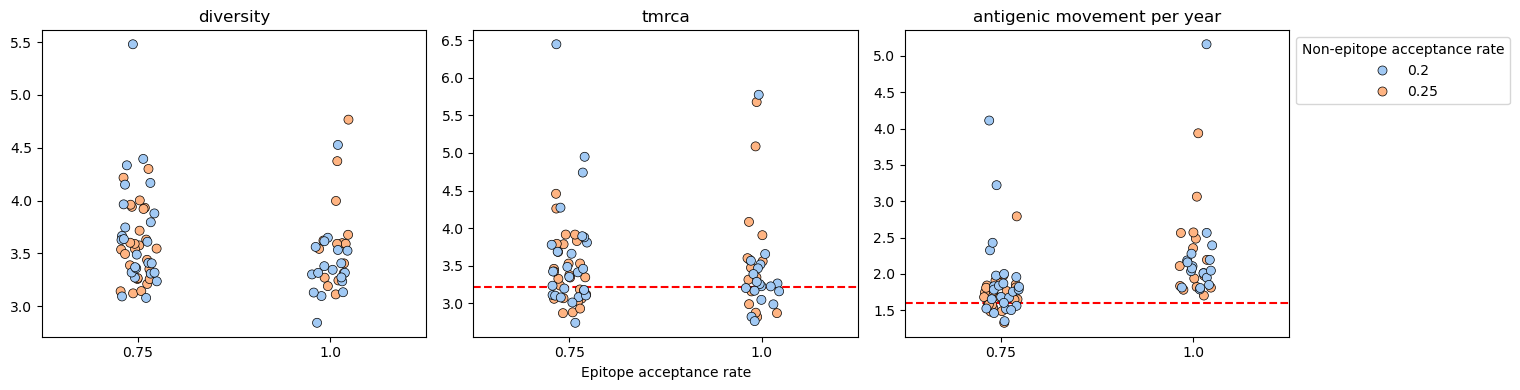

In [7]:
# Specify the columns you want to plot
columns_to_plot = ['diversity', 'tmrca', 'antigenic_movement_per_year']
columns_avgs = [9, 3.22, 1.6, 0.0]
column_avgs_dict = dict(zip(columns_to_plot, columns_avgs))
n_rows = 1
n_cols = 3

# Set up a grid of subplots with 1 rows and 3 columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4), sharex=True)
col_idx = 0
for i in range(n_cols):
    column = columns_to_plot[col_idx]
    col_idx += 1
    seed_jitter()
    sns.stripplot(x='epitope_acceptance', y=column, hue='non_epitope_acceptance', data=filtered_stats_df, ax=axes[i], 
                  jitter=True, size=6.5, edgecolor='black', linewidth=0.5, palette='pastel')
    if i > 0:
        axes[i].axhline(column_avgs_dict[column], ls='--', color='red')
    axes[i].set_ylabel('')
    axes[i].set_title(column.replace('_', ' '))
    axes[i].get_legend().remove()
    if i == 1:
        axes[i].set_xlabel('Epitope acceptance rate')
    else:
        axes[i].set_xlabel('')
    
# Add text to upper left corner of first plot
#axes[0].text(-0.2, 1.05, 'A', transform=axes[0].transAxes, fontsize=16, fontweight='bold', va='top')
axes[2].legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), title='Non-epitope acceptance rate')

# Layout
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Save the figure in both PDF and PNG formats and show
plt.savefig(f'{base_stats_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{base_stats_path}.png', dpi=300, bbox_inches='tight')
print(f"Figure saved to {base_stats_path}.pdf and {base_stats_path}.png")
# Show the plot
plt.show()

In [8]:
# Example usage
summarize_stats(filtered_stats_df, ['diversity', 'tmrca', 'antigenic_movement_per_year'])

,statistic,mean,std_dev
0,diversity,3.576039,0.427208
1,tmrca,3.514531,0.661097
2,antigenic_movement_per_year,1.992081,0.590891


## Sequence mutation summary stats

In [9]:
new_stats_path = f'{fig_dir}/figureS2_new_antigen_summary_stats'

Figure saved to ../../antigen-tex/reviews/round1/figures/figureS2_new_antigen_summary_stats.pdf and ../../antigen-tex/reviews/round1/figures/figureS2_new_antigen_summary_stats.png


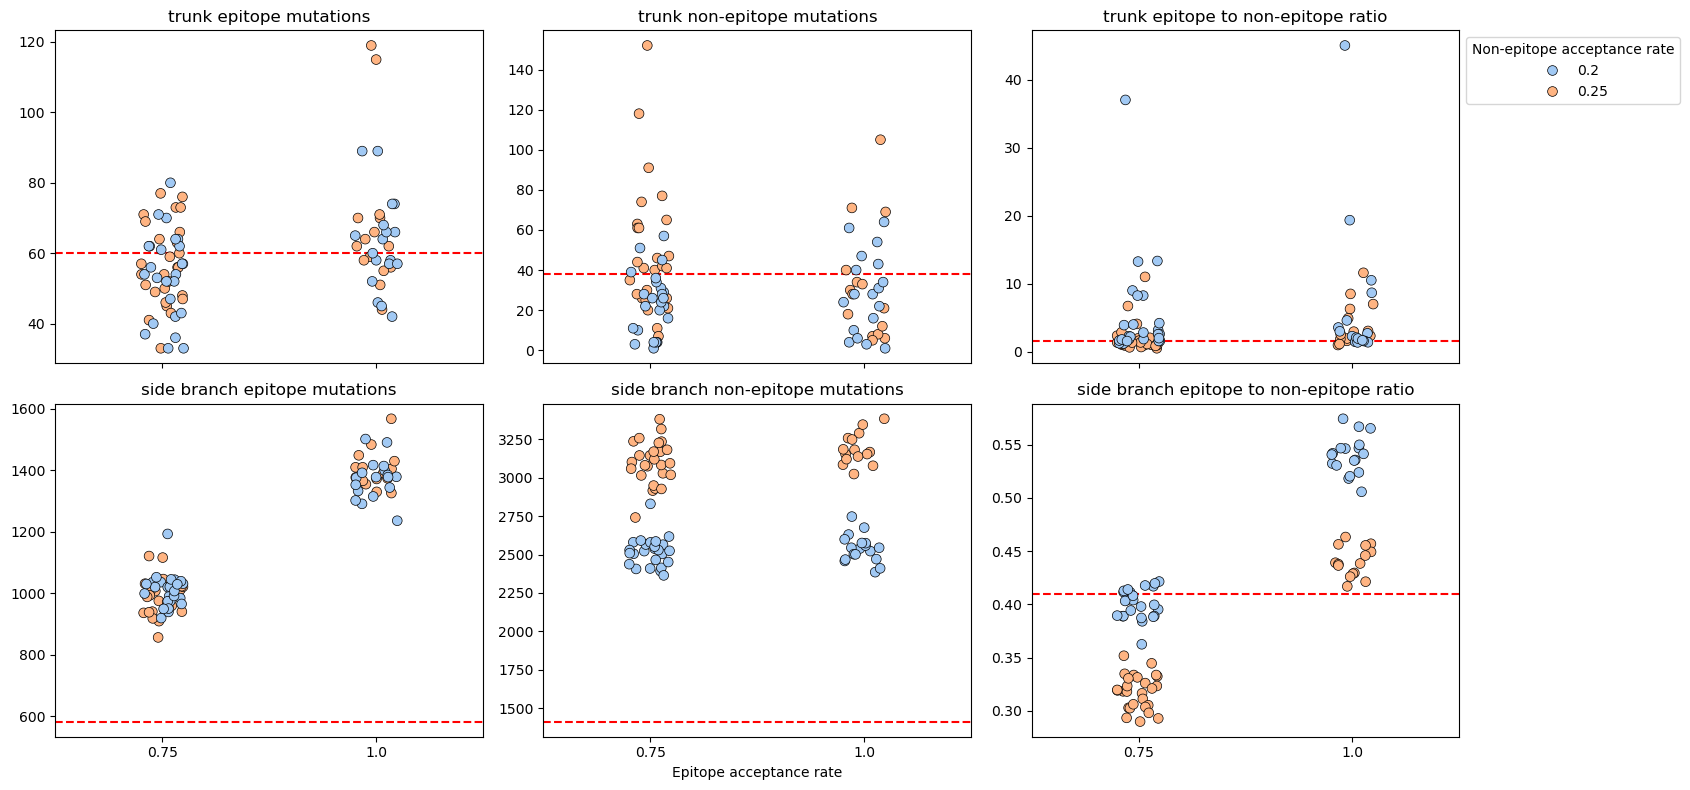

In [10]:
columns_to_plot = ['trunk_epitope_mutations', 'trunk_non-epitope_mutations', 'trunk_epitope_to_non-epitope_ratio', 'side_branch_epitope_mutations', 'side_branch_non-epitope_mutations', 'side_branch_epitope_to_non-epitope_ratio']
columns_avgs = [60, 38, 1.56, 582, 1412, 0.41]
column_avgs_dict = dict(zip(columns_to_plot, columns_avgs))
n_rows = 2
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), sharex=True)
for i in range(n_rows):
    for j in range(n_cols):
        column = columns_to_plot[i*n_cols + j]
        seed_jitter()
    sns.stripplot(x='epitope_acceptance', y=column, hue='non_epitope_acceptance', data=filtered_stats_df, ax=axes[i,j], 
                      jitter=True, size=7.0, edgecolor='black', linewidth=0.5, palette='pastel')
        axes[i,j].set_title(column.replace('_', ' '))
        axes[i,j].axhline(column_avgs_dict[column], ls='--', color='red')
        # Remove legend
        axes[i,j].get_legend().remove()
        if j == 1 and i == 1:
            axes[i,j].set_xlabel('Epitope acceptance rate')
        else:
            axes[i,j].set_xlabel('')
        axes[i,j].set_ylabel('')
# Add legend outside of plot
axes[0,2].legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), title='Non-epitope acceptance rate')

# Add text to upper left corner of first plot
#axes[0,0].text(-0.2, 1.05, 'B', transform=axes[0,0].transAxes, fontsize=16, fontweight='bold', va='top')
# Adjust the layout of the subplots
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(f'{new_stats_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{new_stats_path}.png', dpi=300, bbox_inches='tight')
print(f"Figure saved to {new_stats_path}.pdf and {new_stats_path}.png")
# Show the plot
plt.show()

In [11]:
summarize_stats(filtered_stats_df, columns_to_plot)

,statistic,mean,std_dev
0,trunk_epitope_mutations,59.141176,14.930915
1,trunk_non-epitope_mutations,33.800000,27.210292
2,trunk_epitope_to_non-epitope_ratio,4.240797,6.718613
3,side_branch_epitope_mutations,1148.235294,199.539270
4,side_branch_non-epitope_mutations,2826.376471,324.945306
5,side_branch_epitope_to_non-epitope_ratio,0.411000,0.082255
